In [3]:
# Load development dataset from 01_data_inspection
from pathlib import Path
import pandas as pd

data_path = Path("C:/Users/zeina/data/processed/dev_df.parquet")

dev_df = pd.read_parquet(data_path)

target_col = "isFraud"

print("Development dataset shape:", dev_df.shape)

Development dataset shape: (472432, 434)


# 1.a- EDA: target distribution

In [4]:
# Count fraud vs non-fraud transactions
target_counts = (
    dev_df[target_col]
    .value_counts()
    .sort_index()
    .rename_axis("isFraud")
    .reset_index(name="count")
)

# Add class percentages for easier interpretation
target_counts["percentage"] = target_counts["count"] / len(dev_df)

print("Target distribution in development data:")
display(target_counts)

Target distribution in development data:


,isFraud,count,percentage
0,0,455833,0.964865
1,1,16599,0.035135


# 1.b- Visualize class imbalance

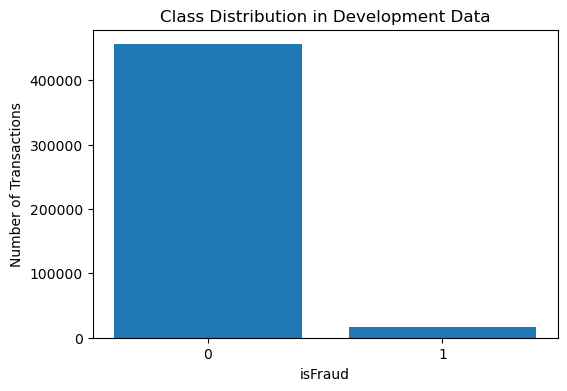

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(target_counts["isFraud"].astype(str), target_counts["count"])

plt.title("Class Distribution in Development Data")
plt.xlabel("isFraud")
plt.ylabel("Number of Transactions")

plt.show()

### Interpretation

The development dataset is strongly imbalanced, with fraudulent transactions representing only a small share of all observations. This confirms that accuracy should not be the primary evaluation metric. Later modeling should emphasize metrics such as precision, recall, PR-AUC, ROC-AUC, and threshold-dependent decision performance.

# 2- Feature Type Profiling

In [7]:
# ---1.Inspect dataframe structure-----------------------------------------------
dev_df.info()

# ---2.Raw pandas dtype distribution---------------------------------------------
feature_types = (
    dev_df.dtypes
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="count")
)

feature_types

# ---3.Separate numeric and categorical feature groups---------------------------
numeric_cols = dev_df.select_dtypes(include=["number"]).columns
categorical_cols = dev_df.select_dtypes(include=["object", "category"]).columns

print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
print(f"Total features: {dev_df.shape[1]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472432 entries, 0 to 472431
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.5+ GB
Numeric features: 403
Categorical features: 31
Total features: 434


# 3- Missingness Analysis

Development rows: 472,432
Total features: 434
Features with missing values: 414


,missing_count,missing_pct,missing_band,feature_type
id_24,468518,0.991715,90-100%,numeric
id_25,468186,0.991012,90-100%,numeric
id_08,468171,0.990981,90-100%,numeric
id_07,468171,0.990981,90-100%,numeric
id_21,468169,0.990976,90-100%,numeric
id_26,468165,0.990968,90-100%,numeric
id_27,468159,0.990955,90-100%,categorical
id_23,468159,0.990955,90-100%,categorical
id_22,468159,0.990955,90-100%,numeric
D7,442488,0.936617,90-100%,numeric


,missing_band,feature_count
0,0-10%,92
1,10-30%,90
2,30-60%,19
3,60-90%,201
4,90-100%,12


,feature_type,feature_count,avg_missing_pct,median_missing_pct
0,categorical,30,0.645023,0.750660
1,numeric,384,0.459009,0.528984


,missing_count,missing_pct,missing_band,feature_type
id_24,468518,0.991715,90-100%,numeric
id_25,468186,0.991012,90-100%,numeric
id_08,468171,0.990981,90-100%,numeric
id_07,468171,0.990981,90-100%,numeric
id_21,468169,0.990976,90-100%,numeric
id_26,468165,0.990968,90-100%,numeric
id_27,468159,0.990955,90-100%,categorical
id_23,468159,0.990955,90-100%,categorical
id_22,468159,0.990955,90-100%,numeric
D7,442488,0.936617,90-100%,numeric


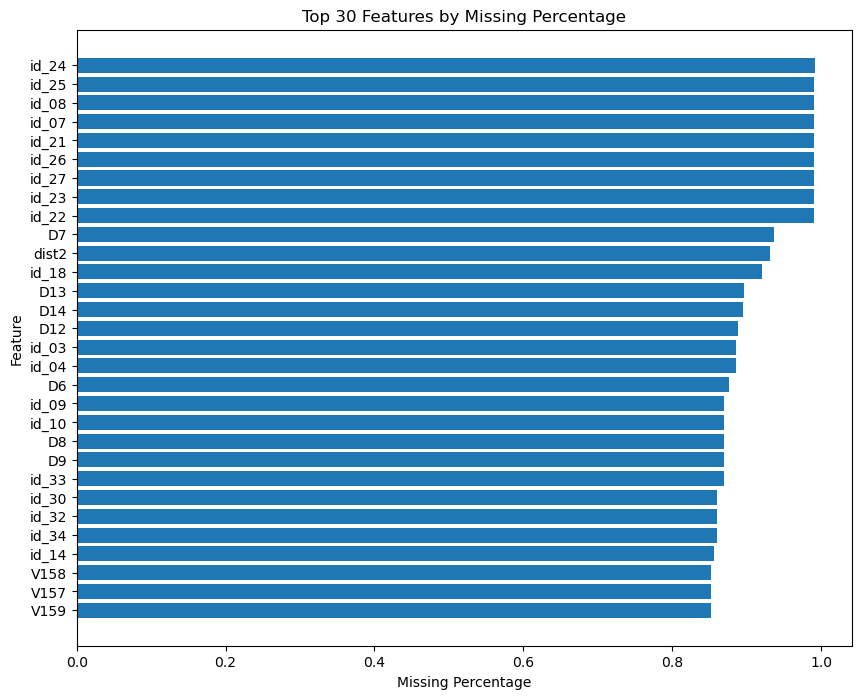

In [8]:
import matplotlib.pyplot as plt

# ---3.1.Build missingness summary---------------------------------------------
# Count missing values and missing percentages for each feature
missing_summary = (
    dev_df.isna()
    .sum()
    .to_frame(name="missing_count")
    .assign(
        missing_pct=lambda df_: df_["missing_count"] / len(dev_df)
    )
    .sort_values("missing_pct", ascending=False)
)

# Keep only features with at least one missing value
missing_summary = missing_summary.loc[missing_summary["missing_count"] > 0].copy()


# ---3.2.Assign missingness severity bands-------------------------------------
# Group features by missingness severity
missing_summary["missing_band"] = pd.cut(
    missing_summary["missing_pct"],
    bins=[0, 0.10, 0.30, 0.60, 0.90, 1.00],
    labels=["0-10%", "10-30%", "30-60%", "60-90%", "90-100%"],
    include_lowest=True
)

missing_band_summary = (
    missing_summary["missing_band"]
    .value_counts()
    .sort_index()
    .rename_axis("missing_band")
    .reset_index(name="feature_count")
)


# ---3.3.Attach feature type labels--------------------------------------------
# Label each feature as numeric or categorical
feature_type_map = pd.Series(index=dev_df.columns, dtype="object")
feature_type_map.loc[numeric_cols] = "numeric"
feature_type_map.loc[categorical_cols] = "categorical"

missing_summary["feature_type"] = missing_summary.index.map(feature_type_map)

missing_by_type = (
    missing_summary.groupby("feature_type")
    .agg(
        feature_count=("missing_count", "size"),
        avg_missing_pct=("missing_pct", "mean"),
        median_missing_pct=("missing_pct", "median")
    )
    .sort_values("avg_missing_pct", ascending=False)
    .reset_index()
)


# ---3.4.Extract top missing features------------------------------------------
# Keep the most incomplete features for review and plotting
top_missing_features = missing_summary.head(30).copy()


# ---3.5.Print key summaries---------------------------------------------------
print(f"Development rows: {len(dev_df):,}")
print(f"Total features: {dev_df.shape[1]:,}")
print(f"Features with missing values: {missing_summary.shape[0]:,}")


# ---3.6.Display missingness tables--------------------------------------------
display(missing_summary.head(20))
display(missing_band_summary)
display(missing_by_type)
display(top_missing_features)


# ---3.7.Visualize top missing features----------------------------------------
plot_df = top_missing_features.sort_values("missing_pct", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(plot_df.index, plot_df["missing_pct"])

plt.title("Top 30 Features by Missing Percentage")
plt.xlabel("Missing Percentage")
plt.ylabel("Feature")

plt.show()

### Interpretation:

Missingness is widespread in the development dataset. Out of 434 features, 414 contain missing values, indicating that missingness is a structural characteristic of the dataset rather than a data quality issue

Several variables exhibit extremely high missingness (above 90%). Many of these features originate from the identity table, which is expected because identity information is only available for a subset of transactios.

The majority of features fall in the 60–90% missing range, suggesting that many variables are conditionally available depending on transaction context or data collection mechansms.

This pattern has important implications for modeling. Missing values should not be treated as simple data errors, and high-missing features should not be dropped automatically. In fraud detection, missingness itself may carry predictive signal. Later stages of the project will therefore consider appropriate imputation strategies and potentially include missing-indicator features when beneficial.

# 4.Feature distributions and early fraud signal


Feature: ProductCD


,ProductCD,transaction_count,fraud_rate
0,W,346001,0.020691
1,C,56410,0.113296
2,R,32203,0.036301
3,H,29691,0.046378
4,S,8127,0.061892



Feature: card4


,card4,transaction_count,fraud_rate
0,visa,308141,0.034724
1,mastercard,150862,0.034906
2,american express,7202,0.028603
3,discover,5394,0.074342
4,NaN,833,0.031212



Feature: card6


,card6,transaction_count,fraud_rate
0,debit,349843,0.023971
1,credit,121716,0.067280
2,NaN,828,0.028986
3,debit or credit,30,0.000000
4,charge card,15,0.000000


,isFraud,count,mean,median,std,min,max
0,0,455833,133.868338,68.500,237.848869,0.251,31937.391
1,1,16599,149.039733,76.129,228.947806,0.292,5191.000


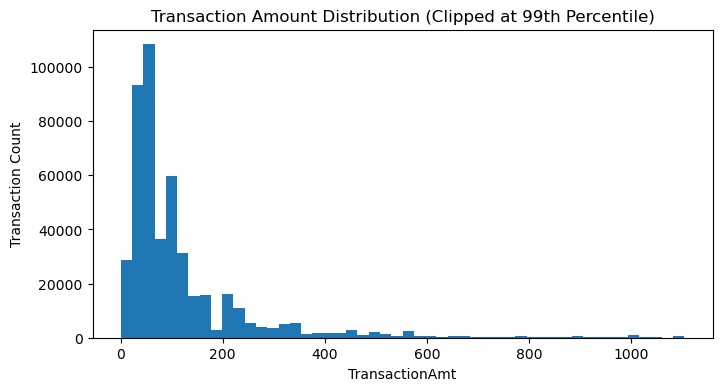

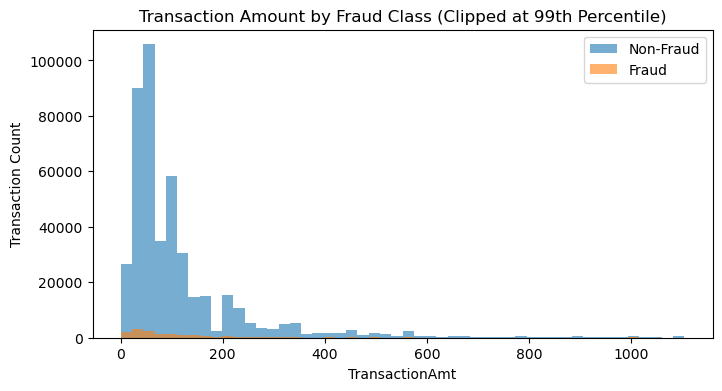

In [9]:
# ---4.1.Fraud rate by key categorical features--------------------------------

# Review fraud rate and transaction volume for core business-facing categoricals
key_categorical_features = ["ProductCD", "card4", "card6"]

for col in key_categorical_features:
    feature_summary = (
        dev_df.groupby(col, dropna=False)[target_col]
        .agg(
            transaction_count="size",
            fraud_rate="mean"
        )
        .sort_values("transaction_count", ascending=False)
        .reset_index()
    )

    print(f"\nFeature: {col}")
    display(feature_summary)


# ---4.2.Transaction amount summary by fraud class-----------------------------

# Compare transaction amount distribution across fraud vs non-fraud classes
transaction_amt_summary = (
    dev_df.groupby(target_col)["TransactionAmt"]
    .agg(
        count="size",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
    .reset_index()
)

display(transaction_amt_summary)


# ---4.3.Transaction amount distribution---------------------------------------

# Plot transaction amount with clipping to improve readability
transaction_amt_clip = dev_df["TransactionAmt"].quantile(0.99)

plot_df = dev_df.loc[
    dev_df["TransactionAmt"] <= transaction_amt_clip,
    ["TransactionAmt", target_col]
].copy()

plt.figure(figsize=(8, 4))
plt.hist(
    plot_df["TransactionAmt"],
    bins=50
)

plt.title("Transaction Amount Distribution (Clipped at 99th Percentile)")
plt.xlabel("TransactionAmt")
plt.ylabel("Transaction Count")
plt.show()


# ---4.4.Transaction amount by fraud class-------------------------------------

# Compare clipped transaction amount distributions by class
nonfraud_amt = plot_df.loc[plot_df[target_col] == 0, "TransactionAmt"]
fraud_amt = plot_df.loc[plot_df[target_col] == 1, "TransactionAmt"]

plt.figure(figsize=(8, 4))
plt.hist(nonfraud_amt, bins=50, alpha=0.6, label="Non-Fraud")
plt.hist(fraud_amt, bins=50, alpha=0.6, label="Fraud")

plt.title("Transaction Amount by Fraud Class (Clipped at 99th Percentile)")
plt.xlabel("TransactionAmt")
plt.ylabel("Transaction Count")
plt.legend()
plt.show()

### Interpretation:

Several interpretable transaction attributes show meaningful differences in fraud risk.

Product category displays the strongest signal. Transactions in category C have a fraud rate above 11%, compared with roughly 2% for the dominant category W. This suggests that transaction type is an important behavioral feature for fraud detection.

Payment network also shows variation. Discover transactions exhibit a higher fraud rate than Visa and Mastercard, although the sample size is smaller.

Card type reveals a clear pattern: credit transactions have a substantially higher fraud rate than debit transactions. This aligns with typical fraud behavior, since credit cards often allow larger purchases and may be more attractive targets for attackers.

Transaction amount is slightly higher on average for fraudulent transactions, although the distributions are highly skewed. This suggests that transaction size alone is unlikely to be a strong predictor, but it may still contribute signal when combined with other variables.

# 5.Transaction amount deeper analysis

,TransactionAmt_bucket,transaction_count,fraud_rate
0,"(0.25, 25.95]",48235,0.054152
1,"(25.95, 35.95]",48945,0.032342
2,"(35.95, 49.0]",51520,0.032395
3,"(49.0, 57.95]",48703,0.019629
4,"(57.95, 68.95]",39585,0.028091
5,"(68.95, 100.0]",59222,0.036422
6,"(100.0, 117.0]",55798,0.019230
7,"(117.0, 159.95]",26190,0.043910
8,"(159.95, 277.0]",46991,0.039199
9,"(277.0, 31937.391]",47243,0.051754


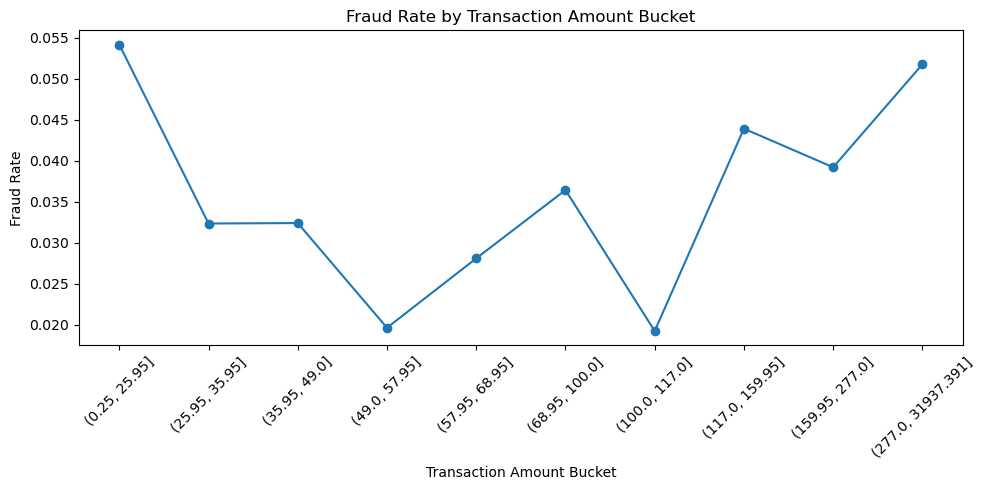

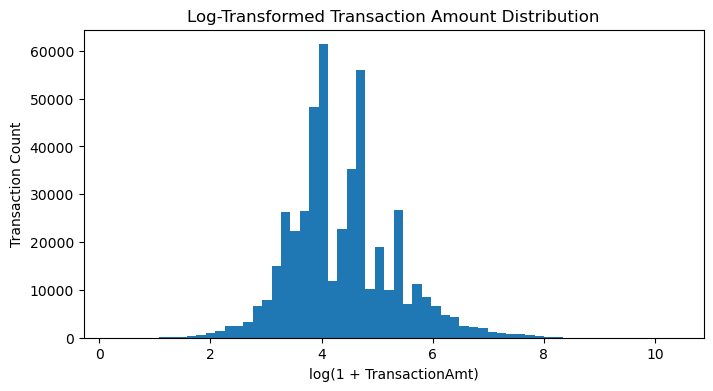

In [11]:
# ---5.1.Create transaction amount buckets------------------------------------

# Create quantile-based buckets so each bucket contains a similar number of transactions
dev_df["TransactionAmt_bucket"] = pd.qcut(
    dev_df["TransactionAmt"],
    q=10,
    duplicates="drop"
)


# ---5.2.Fraud rate by amount bucket------------------------------------------

amount_bucket_summary = (
    dev_df.groupby("TransactionAmt_bucket", observed=True)[target_col]
    .agg(
        transaction_count="size",
        fraud_rate="mean"
    )
    .reset_index()
)

display(amount_bucket_summary)


# ---5.3.Visualize fraud rate by amount bucket--------------------------------

plt.figure(figsize=(10,5))

plt.plot(
    range(len(amount_bucket_summary)),
    amount_bucket_summary["fraud_rate"],
    marker="o"
)

plt.xticks(
    range(len(amount_bucket_summary)),
    amount_bucket_summary["TransactionAmt_bucket"],
    rotation=45
)

plt.title("Fraud Rate by Transaction Amount Bucket")
plt.xlabel("Transaction Amount Bucket")
plt.ylabel("Fraud Rate")

plt.tight_layout()
plt.show()


# ---5.4.Log-transformed transaction amount distribution----------------------

# Fraud datasets often have heavy-tailed monetary distributions
log_amt = np.log1p(dev_df["TransactionAmt"])

plt.figure(figsize=(8,4))
plt.hist(log_amt, bins=60)

plt.title("Log-Transformed Transaction Amount Distribution")
plt.xlabel("log(1 + TransactionAmt)")
plt.ylabel("Transaction Count")

plt.show()

### Interpretation

Fraud risk varies across transaction size rather than increasing linearly with amount. Very small transactions exhibit elevated fraud rates, which is consistent with card testing behavior where attackers validate stolen credentials with small purchases. Fraud risk then decreases for mid-range transactions before rising again for larger purchases.

This non-linear relationship suggests that transaction amount may interact with other variables such as product type or payment method. Tree-based models are well suited to capture these patterns, while linear models may require transformations or interaction features.

The log-transformed distribution confirms that transaction amounts are highly right-skewed, which is typical for payment datasets.

# 6.Environment and identity signals

In [12]:
# ---6.1.Fraud rate by purchaser email domain---------------------------------

# Focus on the most frequent purchaser email domains
top_p_email = dev_df["P_emaildomain"].value_counts().head(10).index

p_email_summary = (
    dev_df.loc[dev_df["P_emaildomain"].isin(top_p_email)]
    .groupby("P_emaildomain", observed=True)[target_col]
    .agg(
        transaction_count="size",
        fraud_rate="mean"
    )
    .sort_values("transaction_count", ascending=False)
    .reset_index()
)

print("\nTop purchaser email domains")
display(p_email_summary)


# ---6.2.Fraud rate by recipient email domain---------------------------------

top_r_email = dev_df["R_emaildomain"].value_counts().head(10).index

r_email_summary = (
    dev_df.loc[dev_df["R_emaildomain"].isin(top_r_email)]
    .groupby("R_emaildomain", observed=True)[target_col]
    .agg(
        transaction_count="size",
        fraud_rate="mean"
    )
    .sort_values("transaction_count", ascending=False)
    .reset_index()
)

print("\nTop recipient email domains")
display(r_email_summary)


# ---6.3.Fraud rate by device type--------------------------------------------

device_type_summary = (
    dev_df.groupby("DeviceType", observed=True)[target_col]
    .agg(
        transaction_count="size",
        fraud_rate="mean"
    )
    .sort_values("transaction_count", ascending=False)
    .reset_index()
)

print("\nDevice type summary")
display(device_type_summary)


# ---6.4.Top device fingerprints----------------------------------------------

# DeviceInfo contains many values, so we focus on the most frequent ones
top_devices = dev_df["DeviceInfo"].value_counts().head(10).index

device_info_summary = (
    dev_df.loc[dev_df["DeviceInfo"].isin(top_devices)]
    .groupby("DeviceInfo", observed=True)[target_col]
    .agg(
        transaction_count="size",
        fraud_rate="mean"
    )
    .sort_values("transaction_count", ascending=False)
    .reset_index()
)

print("\nTop device fingerprints")
display(device_info_summary)


Top purchaser email domains


,P_emaildomain,transaction_count,fraud_rate
0,gmail.com,182692,0.044003
1,yahoo.com,80854,0.022930
2,hotmail.com,37158,0.052021
3,anonymous.com,29961,0.023264
4,aol.com,22618,0.021885
5,comcast.net,6496,0.030018
6,icloud.com,5031,0.031803
7,outlook.com,4080,0.091667
8,msn.com,3340,0.017665
9,att.net,3133,0.006384



Top recipient email domains


,R_emaildomain,transaction_count,fraud_rate
0,gmail.com,47290,0.115162
1,hotmail.com,22984,0.074530
2,anonymous.com,17271,0.028545
3,yahoo.com,8879,0.058340
4,aol.com,3254,0.036878
5,outlook.com,2035,0.156757
6,comcast.net,1578,0.013308
7,yahoo.com.mx,1256,0.011943
8,icloud.com,1138,0.118629
9,msn.com,718,0.001393



Device type summary


,DeviceType,transaction_count,fraud_rate
0,desktop,71545,0.062408
1,mobile,46093,0.099039



Top device fingerprints


,DeviceInfo,transaction_count,fraud_rate
0,Windows,39681,0.062120
1,iOS Device,17083,0.061348
2,MacOS,10843,0.018537
3,Trident/7.0,6453,0.011468
4,rv:11.0,1651,0.041793
5,rv:57.0,957,0.107628
6,SM-J700M Build/MMB29K,441,0.108844
7,SM-G610M Build/MMB29K,385,0.085714
8,SM-G531H Build/LMY48B,341,0.093842
9,SM-G955U Build/NRD90M,313,0.083067


### Interpretation

Environment-related variables show meaningful variation in fraud exposure.

Email domains exhibit different fraud rates, with certain providers such as outlook.com and hotmail.com showing elevated fraud levels. This likely reflects behavioral patterns related to account creation and usage rather than intrinsic properties of the providers themselves.

Recipient email domains show even stronger variation in fraud risk, suggesting that transaction counterpart information may carry predictive signal.

Device context also appears informative. Mobile transactions show a higher fraud rate than desktop transactions, which may reflect differences in transaction environments or attacker behavior.

Device fingerprint values (DeviceInfo) display considerable variation but have high cardinality. These features may require careful encoding strategies during feature engineering to avoid creating excessively large feature spaces.

# 7.Time behavior analysis

,TransactionDT_bucket,transaction_count
0,"(86399.999, 601968.75]",23622
1,"(601968.75, 1120680.6]",23622
2,"(1120680.6, 1600825.9]",23621
3,"(1600825.9, 1957283.4]",23622
4,"(1957283.4, 2310158.25]",23621
5,"(2310158.25, 2918826.5]",23622
6,"(2918826.5, 3526451.95]",23621
7,"(3526451.95, 4222356.8]",23622
8,"(4222356.8, 4927405.6]",23621
9,"(4927405.6, 5592303.5]",23622


,TransactionDT_bucket,transaction_count,fraud_rate
0,"(86399.999, 601968.75]",23622,0.028152
1,"(601968.75, 1120680.6]",23622,0.027136
2,"(1120680.6, 1600825.9]",23621,0.025316
3,"(1600825.9, 1957283.4]",23622,0.023410
4,"(1957283.4, 2310158.25]",23621,0.015622
5,"(2310158.25, 2918826.5]",23622,0.036280
6,"(2918826.5, 3526451.95]",23621,0.037594
7,"(3526451.95, 4222356.8]",23622,0.038396
8,"(4222356.8, 4927405.6]",23621,0.043097
9,"(4927405.6, 5592303.5]",23622,0.044958


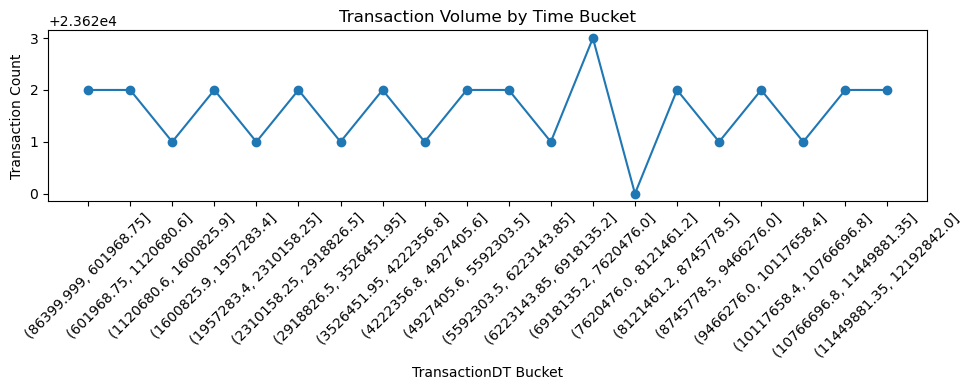

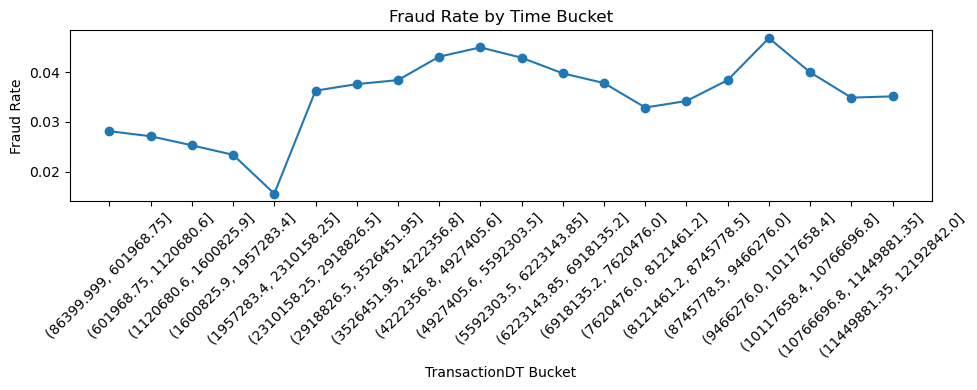

In [13]:
# ---7.1.Create time buckets---------------------------------------------------

# Bucket transactions across the observed time range
dev_df["TransactionDT_bucket"] = pd.qcut(
    dev_df["TransactionDT"],
    q=20,
    duplicates="drop"
)


# ---7.2.Transaction volume by time bucket-------------------------------------

time_volume_summary = (
    dev_df.groupby("TransactionDT_bucket", observed=True)
    .size()
    .reset_index(name="transaction_count")
)

display(time_volume_summary)


# ---7.3.Fraud rate by time bucket---------------------------------------------

time_fraud_summary = (
    dev_df.groupby("TransactionDT_bucket", observed=True)[target_col]
    .agg(
        transaction_count="size",
        fraud_rate="mean"
    )
    .reset_index()
)

display(time_fraud_summary)


# ---7.4.Visualize transaction volume over time--------------------------------

plt.figure(figsize=(10, 4))
plt.plot(
    range(len(time_volume_summary)),
    time_volume_summary["transaction_count"],
    marker="o"
)

plt.xticks(
    range(len(time_volume_summary)),
    time_volume_summary["TransactionDT_bucket"],
    rotation=45
)

plt.title("Transaction Volume by Time Bucket")
plt.xlabel("TransactionDT Bucket")
plt.ylabel("Transaction Count")

plt.tight_layout()
plt.show()


# ---7.5.Visualize fraud rate over time----------------------------------------

plt.figure(figsize=(10, 4))
plt.plot(
    range(len(time_fraud_summary)),
    time_fraud_summary["fraud_rate"],
    marker="o"
)

plt.xticks(
    range(len(time_fraud_summary)),
    time_fraud_summary["TransactionDT_bucket"],
    rotation=45
)

plt.title("Fraud Rate by Time Bucket")
plt.xlabel("TransactionDT Bucket")
plt.ylabel("Fraud Rate")

plt.tight_layout()
plt.show()

### Interpretation

Fraud prevalence varies across the timeline represented by TransactionDT. Early portions of the dataset show fraud rates around 2–3%, while later intervals reach values above 4%. This indicates that fraud behavior is not stationary and evolves over time.

Because of this temporal variation, a time-based holdout split is appropriate for model evaluation. Training on earlier transactions and evaluating on later transactions better reflects real-world deployment, where models must predict fraud on future activity rather than randomly shuffled historical data.